First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset after removing duplicates:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      18

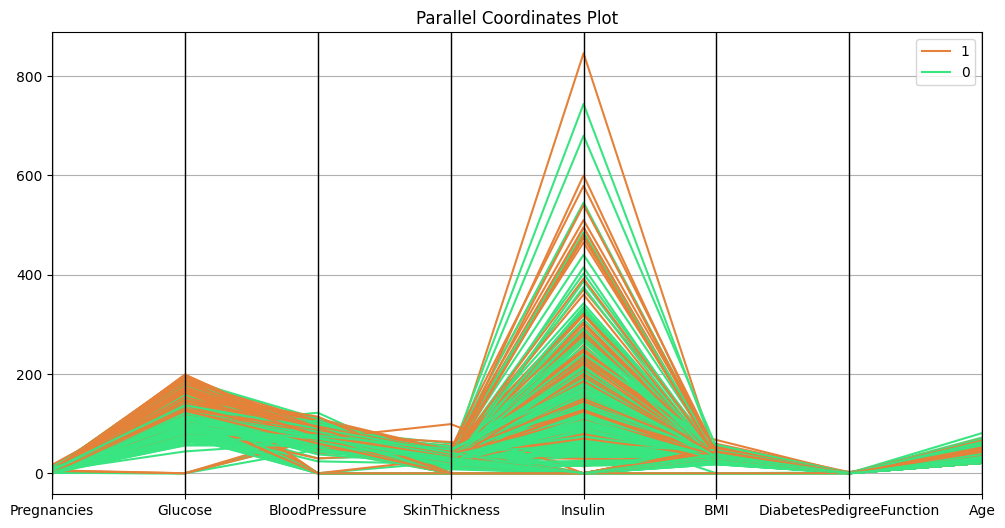

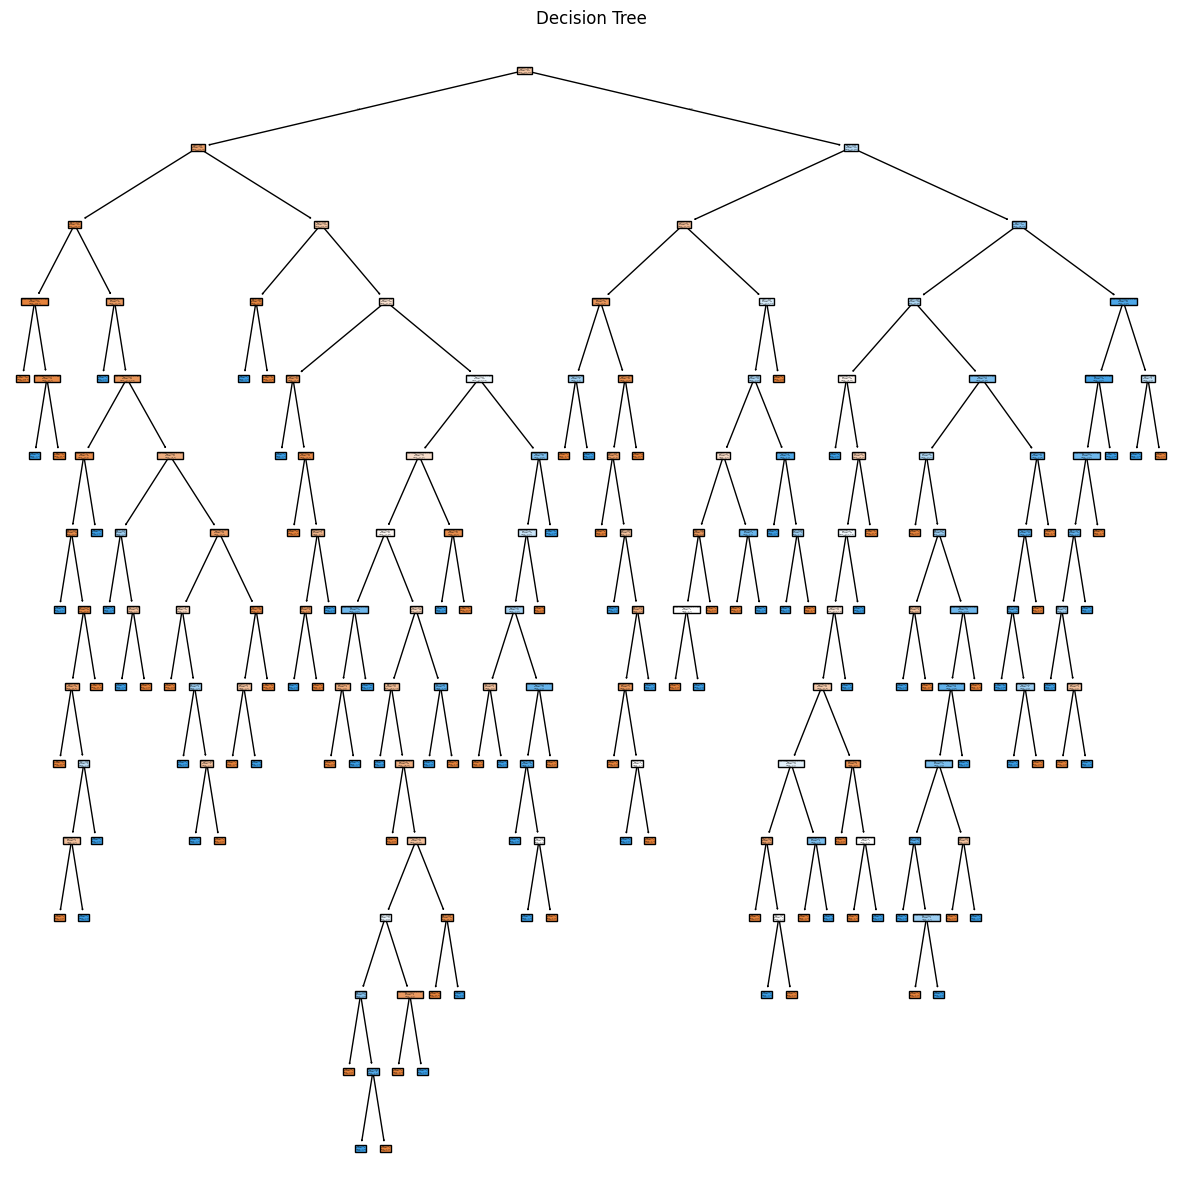


Predictions:
[0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 1 1
 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0
 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]

Initial Accuracy: 0.7597402597402597

Best hyperparameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

Optimized Predictions:
[0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0]

Optimized Accuracy: 0.7727272727272727


In [6]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from pickle import dump


# 2. Load the dataset
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
total_data = pd.read_csv(url)

print("First 5 rows of the dataset:")
print(total_data.head())


# 3. Basic data cleaning
total_data = total_data.drop_duplicates().reset_index(drop=True)

print("\nDataset after removing duplicates:")
print(total_data.head())


# 4. Feature selection
X = total_data.drop("Outcome", axis=1)
y = total_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

selection_model = SelectKBest(k=7)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]

X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns)

print("\nSelected features:")
print(selected_columns)


# 5. Save processed datasets
import os
os.makedirs("../data/processed", exist_ok=True)

# Save processed datasets
X_train_sel["Outcome"] = y_train.values
X_test_sel["Outcome"] = y_test.values

X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)


# 6. Load processed datasets
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

print("\nTraining data preview:")
print(train_data.head())


# 7. Data visualization
plt.figure(figsize=(12, 6))
pd.plotting.parallel_coordinates(
    total_data,
    "Outcome",
    color=("#E58139", "#39E581")
)
plt.title("Parallel Coordinates Plot")
plt.show()


# 8. Prepare training and test data
X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]

X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]


# 9. Train decision tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


# 10. Visualize decision tree
plt.figure(figsize=(15, 15))
tree.plot_tree(
    model,
    feature_names=list(X_train.columns),
    class_names=["0", "1"],
    filled=True
)
plt.title("Decision Tree")
plt.show()


# 11. Make predictions
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)


# 12. Evaluate initial model
initial_accuracy = accuracy_score(y_test, y_pred)
print("\nInitial Accuracy:", initial_accuracy)


# 13. Model optimization with GridSearchCV
hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    hyperparams,
    scoring="accuracy",
    cv=10
)

grid.fit(X_train, y_train)

print("\nBest hyperparameters:")
print(grid.best_params_)


# 14. Train optimized model
optimized_model = DecisionTreeClassifier(
    criterion=grid.best_params_["criterion"],
    max_depth=grid.best_params_["max_depth"],
    min_samples_split=grid.best_params_["min_samples_split"],
    min_samples_leaf=grid.best_params_["min_samples_leaf"],
    random_state=42
)

optimized_model.fit(X_train, y_train)


# 15. Evaluate optimized model
optimized_pred = optimized_model.predict(X_test)
optimized_accuracy = accuracy_score(y_test, optimized_pred)

print("\nOptimized Predictions:")
print(optimized_pred)

print("\nOptimized Accuracy:", optimized_accuracy)
